In [38]:

from TetriumColor.Utils.ParserOptions import AddObserverArgs, AddVideoOutputArgs, AddAnimationArgs
from TetriumColor.Observer import Observer, Spectra, Pigment, InkGamut, Illuminant, Neugebauer, InkLibrary, load_top_inks, show_top_k_combinations, InkLibrary, plot_inks_by_hue, save_top_inks_as_csv, load_all_ink_libraries, combine_inksets, load_inkset
from TetriumColor import ColorSpace, ColorSpaceType, PolyscopeDisplayType
from TetriumColor.Measurement.Nix import read_nix_csv
from library_registry import registry
import numpy as np
np.set_printoptions(precision=3, suppress=True)
import numpy.typing as npt
from typing import Dict, Tuple, List
import argparse
import os
import sys
import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
from TetriumColor.Observer.Inks import load_primaries_from_registry

In [41]:
primaries_dict = load_primaries_from_registry("CMYO-10-12")
ink_gamut = InkGamut(primaries_dict, primaries_dict["0000"], calibration_json="./results/model-10-12.json" )

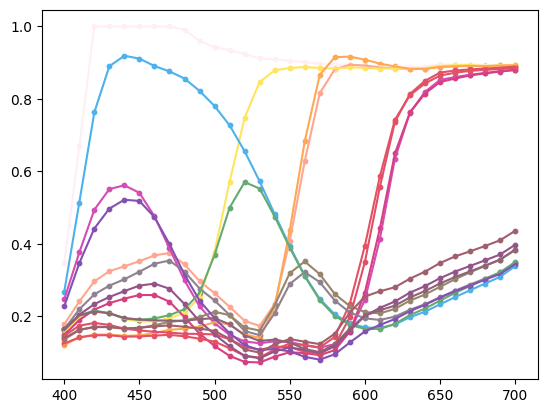

In [42]:
for k, b in primaries_dict.items():
    b.plot(name=k, color=b.to_rgb())
plt.show()

In [43]:
illuminant = Illuminant.get('D50')
observer = Observer.tetrachromat(illuminant=illuminant)

In [63]:
metamers = ink_gamut.get_buckets(observer, stepsize=0.02)
# spectra_metamers = [[ink_gamut.get_spectra(m[1][0]), ink_gamut.get_spectra(m[1][1])] for m in metamers]
# delta_Es = [Spectra.delta_e(s1, s2) for s1, s2 in spectra_metamers]
# rgbs = [(s1.to_rgb(), s2.to_rgb()) for s1, s2 in spectra_metamers]

Generating point cloud: 68it [00:10,  6.72it/s]                        


Point cloud generated.


In [77]:
repr(np.flip((np.array(metamers[5][1]) * 255).astype(int)))

'array([[ 30,   5,   5, 224],\n       [  0,  91, 107,  10]])'

In [ ]:
top_k_delta_E_metamers = [spectra_metamers[i] for i in np.argsort(delta_Es)[:100]]
top_k_delta_E = [delta_Es[i] for i in np.argsort(delta_Es)[:100]]
delta_E_balls = [[s1.avg_delta_e_unit(illuminant), s2.avg_delta_e_unit(illuminant)] for s1, s2 in tqdm(top_k_delta_E_metamers)]

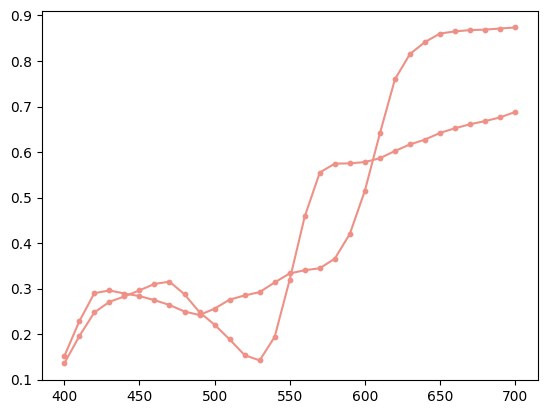

In [76]:
i = 5
ink_gamut.get_spectra(metamers[i][1][0]).plot(name="primary 0", color=ink_gamut.get_spectra(metamers[i][1][0]).to_rgb())
ink_gamut.get_spectra(metamers[i][1][1]).plot(name="primary 1", color=ink_gamut.get_spectra(metamers[i][1][1]).to_rgb())
plt.show()

In [ ]:
measured_dict, _ = read_nix_csv(Path("./data/measurements/2025-10-7/metamers-10-7.csv"))
measured_spectras = list(measured_dict.values())[2:]
# measured_spectras = [Spectra(wavelengths=s.wavelengths, data=s.data * 1.2) for s in measured_dict.values()]

In [ ]:
orig_spectra = ink_gamut.get_spectra(metamers[0][1][0])
fig = plt.figure()
[s.plot(name=f"Primary {i} if i set it to put no yellow ink down", color=s.to_rgb()) for i, s in enumerate(spectras) if i == 0]
[s.plot(name=f"Measured {i}", color=s.to_rgb()) for i, s in enumerate(measured_spectras) if i == 0]
measured_spectras[-1].plot(name="measured after putting more yellow ink down", color=measured_spectras[-1].to_rgb())
orig_spectra.plot(name="original primary 0", color=orig_spectra.to_rgb())
plt.legend()
plt.show()